# 교사 엔트로피 $H(P_t)$ 축 위의 세 구역

DINO 사전학습에는 검증이 없다. loss는 붕괴할수록 오히려 **더 잘 내려간다**.
그래서 실제로 봐야 하는 진단량은 교사 분포의 모양, 그 중에서도 엔트로피다.

$$
H(P_t) \;=\; -\sum_{k=1}^{K} P_t(k)\,\log P_t(k)
\;\in\; [\,0,\ \log K\,]
$$

| 구역 | 값 | 의미 |
|---|---|---|
| 왼쪽 끝 | $H \to 0$ | 항상 같은 one-hot → **단일 프로토타입 붕괴** (centering 실패) |
| 오른쪽 끝 | $H \to \log K$ | 모든 입력이 $1/K$ flat → **uniform 붕괴** (sharpening 실패) |
| 그 사이 | $0 \ll H \ll \log K$ | 두 힘이 균형 잡힌 **건강한 "매달린" 상태** |

이 스크립트는 $K = 4096$ 에서
(1) 세 합성 분포를 축 위에 찍어 보고,
(2) 온도 $\tau$ 하나로 엔트로피가 $0 \leftrightarrow \log K$ 를 연속으로 오가는 것을 보고,
(3) 워크스루 §11 실측값을 시작/끝점으로 삼은 세 가지 "학습 궤적"에 경보선을 얹고,
(4) 엔트로피와 top-1 확률이 단조로 얽혀 있음을 확인한다.

In [1]:
# 필요 패키지: numpy, plotly, kaleido  (torch 불필요 — numpy만으로 계산)
import os
import math

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:                      # 대화형 환경
    HERE = os.getcwd()

RNG = np.random.default_rng(0)
FONT = "Noto Sans CJK KR, Noto Sans KR, DejaVu Sans"

K = 4096                               # 워크스루의 OUT_DIM
LOGK = math.log(K)
print(f"K = {K},  log K = {LOGK:.4f} nats,  1/K = {1/K:.6f}")


def entropy(p, axis=-1):
    """행별 섀넌 엔트로피 [nats]."""
    p = np.asarray(p, dtype=np.float64)
    return -(p * np.log(np.clip(p, 1e-300, None))).sum(axis=axis)


def softmax(z, tau=1.0, axis=-1):
    x = np.asarray(z, dtype=np.float64) / tau
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

K = 4096,  log K = 8.3178 nats,  1/K = 0.000244


## 1. $K$ 별 $\log K$ — 축의 오른쪽 끝은 $K$ 가 정한다

엔트로피의 절대값은 $K$ 를 모르면 해석할 수 없다. 항상 $\log K$ 대비 비율로 본다.

In [2]:
for k in (512, 4096, 65536):
    print(f"K={k:6d}  log K = {math.log(k):7.4f}   (DINO 기본값 K=65536)")

K=   512  log K =  6.2383   (DINO 기본값 K=65536)
K=  4096  log K =  8.3178   (DINO 기본값 K=65536)
K= 65536  log K = 11.0904   (DINO 기본값 K=65536)


## 2. 세 합성 분포를 축 위에 찍기

- **one-hot**: 한 프로토타입에 $1-\varepsilon$ → $H \approx 0$
- **uniform**: 모든 $k$ 에 $1/K$ → $H = \log K$
- **건강**: 소수의 프로토타입에 확률이 몰려 있지만 여전히 여러 개가 살아 있는 분포.
  워크스루 §11 의 정상 실측 $H \approx 7.3$ 에 맞추려고 랜덤 로짓의 온도를 이분법으로 조정했다.
- **sparse-50**: 참고용 — 50개 프로토타입에만 균등, $H = \log 50 \approx 3.91$

In [3]:
eps = 1e-6
p_onehot = np.full(K, eps / (K - 1))
p_onehot[0] = 1.0 - eps

p_uniform = np.full(K, 1.0 / K)

p_sparse50 = np.zeros(K)
p_sparse50[:50] = 1.0 / 50

# 목표 엔트로피(7.30 nats)를 내는 온도를 이분법으로 찾는다
z_base = RNG.standard_normal(K)


def tau_for_entropy(z, target, lo=1e-3, hi=1e3, iters=200):
    for _ in range(iters):
        mid = math.sqrt(lo * hi)
        if entropy(softmax(z, mid)) < target:   # H는 tau에 대해 단조 증가
            lo = mid
        else:
            hi = mid
    return math.sqrt(lo * hi)


tau_healthy = tau_for_entropy(z_base, 7.30)
p_healthy = softmax(z_base, tau_healthy)

dists = {
    "one-hot (단일 붕괴)": p_onehot,
    "sparse-50 (참고)": p_sparse50,
    "건강 (H≈7.3)": p_healthy,
    "uniform (uniform 붕괴)": p_uniform,
}
print(f"목표 H=7.30 을 만드는 tau = {tau_healthy:.4f}\n")
print(f"{'분포':26s} {'H [nats]':>10s} {'H/logK':>8s} {'top-1 p':>9s} {'유효 프로토타입 exp(H)':>22s}")
for name, p in dists.items():
    H = entropy(p)
    print(f"{name:26s} {H:10.4f} {H/LOGK:8.3f} {p.max():9.4f} {math.exp(H):22.1f}")

목표 H=7.30 을 만드는 tau = 0.6734

분포                           H [nats]   H/logK   top-1 p        유효 프로토타입 exp(H)
one-hot (단일 붕괴)                0.0000    0.000    1.0000                    1.0
sparse-50 (참고)                 3.9120    0.470    0.0200                   50.0
건강 (H≈7.3)                     7.3000    0.878    0.0107                 1480.3
uniform (uniform 붕괴)           8.3178    1.000    0.0002                 4096.0


$\exp(H)$ 는 "몇 개의 프로토타입이 실질적으로 살아 있나"(perplexity)로 읽으면 편하다.
건강한 $H=7.3$ 은 $K=4096$ 중 약 1480개가 살아 있다는 뜻 — 붕괴(1개)와 무의미(4096개) 사이다.

## 3. 온도 $\tau$ 하나가 축 전체를 훑는다

같은 로짓이라도 $\tau \to 0$ 이면 one-hot($H\to 0$), $\tau \to \infty$ 면 uniform($H \to \log K$).
그래서 **sharpening**($\tau_t = 0.04$)은 왼쪽으로, **centering**은 오른쪽(정확히는 분포를 흩어)으로 민다.
DINO는 $\tau_t < \tau_s = 0.1$ 이라는 부등호로 교사를 학생보다 왼쪽에 세워 학습 신호를 만든다.

In [4]:
taus = np.logspace(-2.0, 1.5, 120)
Z = RNG.standard_normal((256, K)) * 0.5          # 배치 256개의 교사 로짓
H_sweep = np.array([entropy(softmax(Z, t)).mean() for t in taus])
norm_sweep = H_sweep / LOGK

for t in (0.02, 0.04, 0.1, 1.0, 10.0):
    h = entropy(softmax(Z, t)).mean()
    print(f"tau={t:6.2f}   H={h:7.4f}   H/logK={h/LOGK:.3f}")

tau=  0.02   H= 0.2475   H/logK=0.030
tau=  0.04   H= 0.5693   H/logK=0.068
tau=  0.10   H= 2.0711   H/logK=0.249
tau=  1.00   H= 8.1926   H/logK=0.985
tau= 10.00   H= 8.3165   H/logK=1.000


## 4. 합성 학습 궤적 + 경보선

워크스루 §11 의 실측(3 epoch 미니 학습, $K=4096$)을 시작/끝점으로 삼는다.

| 설정 | $H(P_t)$ 끝값 | $H/\log K$ | 판정 |
|---|---|---|---|
| DINO (center + sharpen) | 7.2 ~ 7.4 | 0.87 ~ 0.89 | 건강 — 두 끝 사이에 **매달림** |
| centering 제거 | 5.86 이고 **계속 하강 중** | 0.70 ↓ | 단일 프로토타입 붕괴로 가는 중 |
| sharpening 제거 ($\tau_t=\tau_s$) | $\approx 8.33 \approx \log K$ | 1.00 (정지) | uniform 붕괴 |

핵심은 **절대값이 아니라 추세**다. 5.86 자체는 "낮아서 나쁜" 값이 아니다 —
계속 내려가고 있고 top-1이 올라가고 argmax 다양성이 줄기 때문에 붕괴다.

경보 임계값 예시: $H/\log K > 0.95$ 가 수백 step 정지(uniform 의심),
$H/\log K < 0.2$ (단일 붕괴 확정), 그리고 최근 500 step 기울기가 지속 음수(하강 추세).

In [5]:
T = 600                                            # step
t_axis = np.arange(T)

# (a) 정상: log K 근처에서 출발해 7.3 부근으로 안착 후 진동
normal = 7.3 + (LOGK - 7.3) * np.exp(-t_axis / 90.0) + RNG.normal(0, 0.045, T)

# (b) 단일 프로토타입 붕괴: 8.3 -> 5.86 (관측 구간), 이후 같은 지수율로 0 을 향해 외삽
k_decay = -math.log(5.86 / LOGK) / (T - 1)
single = LOGK * np.exp(-k_decay * t_axis) + RNG.normal(0, 0.03, T)
t_ext = np.arange(T, 3 * T)
single_ext = LOGK * np.exp(-k_decay * t_ext)       # 점선 외삽

# (c) uniform 붕괴: log K 에 붙어 꼼짝 않음
uniform_run = np.full(T, LOGK) - np.abs(RNG.normal(0, 0.004, T))

HI, LO = 0.95 * LOGK, 0.20 * LOGK
print(f"경보선: 0.95*logK = {HI:.3f},  0.20*logK = {LO:.3f}\n")


def slope(x, w=200):
    return float(np.polyfit(np.arange(w), x[-w:], 1)[0]) * 100  # per 100 step


for nm, x in (("정상", normal), ("no-center", single), ("no-sharpen", uniform_run)):
    h_end = x[-20:].mean()      # §11 과 같은 "마지막 20 step 평균"
    print(f"{nm:11s} H끝={h_end:6.3f}  H/logK={h_end/LOGK:5.3f}  "
          f"최근기울기={slope(x):+7.4f}/100step  "
          f"판정={'uniform 붕괴' if h_end > HI else ('단일 붕괴' if h_end < LO else ('하강 추세 경보' if slope(x) < -0.05 else '건강'))}")

경보선: 0.95*logK = 7.902,  0.20*logK = 1.664

정상          H끝= 7.287  H/logK=0.876  최근기울기=-0.0143/100step  판정=건강
no-center   H끝= 5.900  H/logK=0.709  최근기울기=-0.3615/100step  판정=하강 추세 경보
no-sharpen  H끝= 8.315  H/logK=1.000  최근기울기=-0.0002/100step  판정=uniform 붕괴


정상 곡선도 학습 초반에는 $0.95\log K$ 위에 있다 — 대부분의 프로토타입이 아직 비어 있기 때문이다.
그래서 `0.95` 선은 "**정체**했을 때만" 경보다. 반대로 no-center 는 아직 0.2 선을 넘지 않았는데도
기울기 하나로 잡힌다.

## 5. 엔트로피와 top-1 확률은 단조로 얽혀 있다

$\max_k P_t(k) \to 1$ 은 $H \to 0$ 의 다른 얼굴이다. 그래서 둘을 같이 로깅해도
새 정보가 크게 늘지는 않는다. **엔트로피가 못 잡는 것은 marginal 불균형** —
배치마다 다른 프로토타입을 골라도 항상 같은 소수 집합만 쓰면 $H$ 는 멀쩡하다.
그래서 `argmax 다양성`과 `center 노름`을 함께 봐야 한다.

In [6]:
H_list, top1_list = [], []
for t in taus:
    p = softmax(Z[:64], t)
    H_list.append(entropy(p).mean())
    top1_list.append(p.max(-1).mean())
H_pts = np.array(H_list)
top1_pts = np.array(top1_list)

corr = np.corrcoef(H_pts / LOGK, top1_pts)[0, 1]
print(f"H/logK 와 top-1 의 상관계수 = {corr:.4f}  (단조 감소 관계)")
print(f"H/logK=0.878(건강) 근처의 top-1 ≈ "
      f"{top1_pts[np.argmin(np.abs(H_pts / LOGK - 0.878))]:.5f}   (1/K = {1/K:.5f})")

H/logK 와 top-1 의 상관계수 = -0.9786  (단조 감소 관계)
H/logK=0.878(건강) 근처의 top-1 ≈ 0.01573   (1/K = 0.00024)


## 6. 4패널 그림

좌상: 축 위의 세(+1) 분포 · 우상: 온도 스윕 · 좌하: 궤적 + 경보선 · 우하: $H$ vs top-1

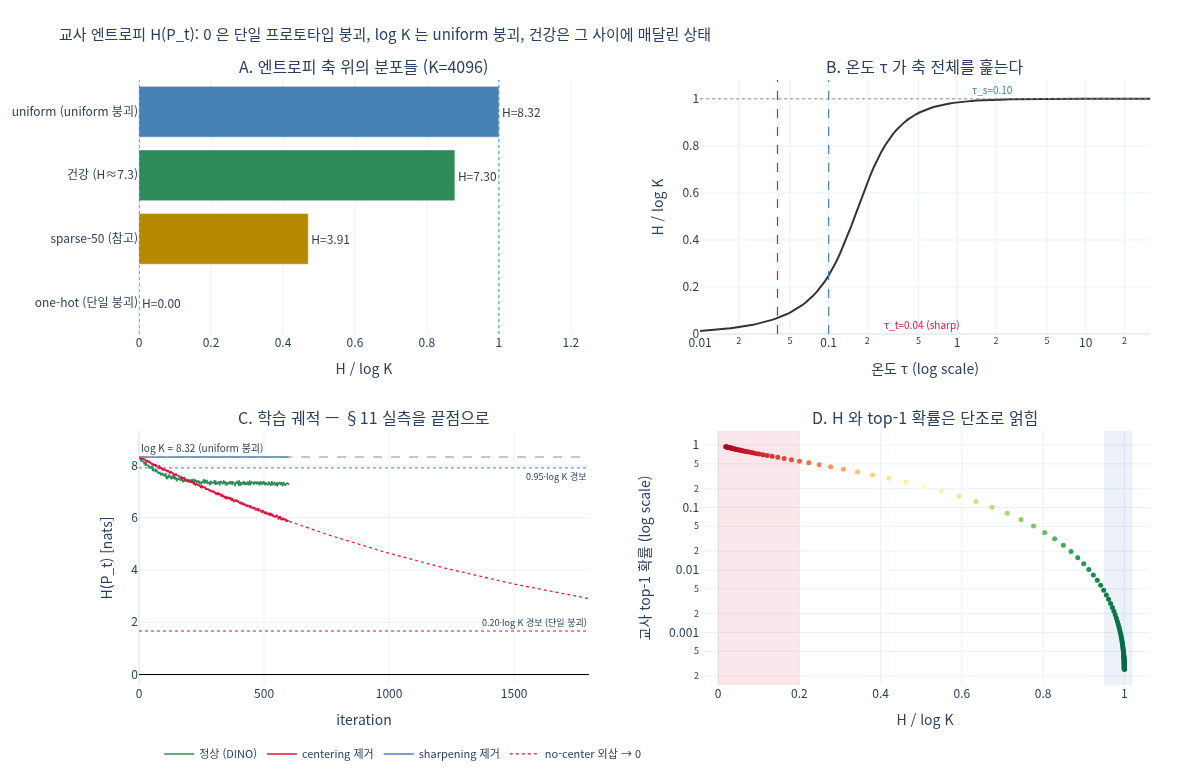

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/cb090713-de5d-440d-8d2e-51f2770e2838/expy.png


In [7]:
GREEN, RED, BLUE, GRAY = "#2e8b57", "#dc143c", "#4682b4", "#8a8f98"

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "A. 엔트로피 축 위의 분포들 (K=4096)",
        "B. 온도 τ 가 축 전체를 훑는다",
        "C. 학습 궤적 — §11 실측을 끝점으로",
        "D. H 와 top-1 확률은 단조로 얽힘",
    ),
    horizontal_spacing=0.11, vertical_spacing=0.16,
)

# --- A: 정규화 엔트로피 막대
names = list(dists.keys())
vals = [entropy(p) / LOGK for p in dists.values()]
fig.add_trace(go.Bar(
    x=vals, y=names, orientation="h",
    marker_color=[RED, "#b58900", GREEN, BLUE],
    text=[f"H={entropy(p):.2f}" for p in dists.values()],
    textposition="outside", cliponaxis=False, showlegend=False,
), row=1, col=1)
fig.add_vline(x=0.0, line=dict(color=RED, dash="dot", width=1), row=1, col=1)
fig.add_vline(x=1.0, line=dict(color=BLUE, dash="dot", width=1), row=1, col=1)

# --- B: 온도 스윕
fig.add_trace(go.Scatter(x=taus, y=norm_sweep, mode="lines",
                         line=dict(color="#333", width=2), showlegend=False), row=1, col=2)
for t, c, lbl, pos in ((0.04, RED, "τ_t=0.04 (sharp)", "bottom left"),
                       (0.1, BLUE, "τ_s=0.10", "top right")):
    fig.add_vline(x=t, line=dict(color=c, width=1.2, dash="dash"),
                  annotation_text=lbl, annotation_font_size=10,
                  annotation_position=pos,
                  annotation_font_color=c, row=1, col=2)
fig.add_hline(y=1.0, line=dict(color=GRAY, dash="dot", width=1), row=1, col=2)

# --- C: 궤적
for nm, y, c in (("정상 (DINO)", normal, GREEN),
                 ("centering 제거", single, RED),
                 ("sharpening 제거", uniform_run, BLUE)):
    fig.add_trace(go.Scatter(x=t_axis, y=y, mode="lines", name=nm,
                             line=dict(color=c, width=1.4)), row=2, col=1)
fig.add_trace(go.Scatter(x=t_ext, y=single_ext, mode="lines", name="no-center 외삽 → 0",
                         line=dict(color=RED, width=1.2, dash="dot")), row=2, col=1)
fig.add_hline(y=LOGK, line=dict(color=GRAY, dash="dash", width=1),
              annotation_text="log K = 8.32 (uniform 붕괴)", annotation_font_size=10,
              annotation_position="top left", row=2, col=1)
fig.add_hline(y=HI, line=dict(color=BLUE, dash="dot", width=1),
              annotation_text="0.95·log K 경보", annotation_font_size=9,
              annotation_position="bottom right", row=2, col=1)
fig.add_hline(y=LO, line=dict(color=RED, dash="dot", width=1),
              annotation_text="0.20·log K 경보 (단일 붕괴)", annotation_font_size=9,
              annotation_position="top right", row=2, col=1)
fig.add_hline(y=0.0, line=dict(color="#000", width=1), row=2, col=1)

# --- D: H vs top-1
fig.add_trace(go.Scatter(
    x=H_pts / LOGK, y=top1_pts, mode="markers",
    marker=dict(size=5, color=H_pts / LOGK, colorscale="RdYlGn", showscale=False),
    showlegend=False), row=2, col=2)
fig.add_vrect(x0=0.0, x1=0.20, fillcolor=RED, opacity=0.10, line_width=0, row=2, col=2)
fig.add_vrect(x0=0.95, x1=1.02, fillcolor=BLUE, opacity=0.10, line_width=0, row=2, col=2)

fig.update_xaxes(title_text="H / log K", range=[0, 1.25], row=1, col=1)
fig.update_xaxes(title_text="온도 τ (log scale)", type="log", row=1, col=2)
fig.update_yaxes(title_text="H / log K", range=[0, 1.08], row=1, col=2)
fig.update_xaxes(title_text="iteration", row=2, col=1)
fig.update_yaxes(title_text="H(P_t) [nats]", range=[-0.4, LOGK * 1.12], row=2, col=1)
fig.update_xaxes(title_text="H / log K", row=2, col=2)
fig.update_yaxes(title_text="교사 top-1 확률 (log scale)", type="log", row=2, col=2)

fig.update_layout(
    height=780, width=1180, template="plotly_white",
    font=dict(family=FONT, size=12),
    title=dict(text="교사 엔트로피 H(P_t): 0 은 단일 프로토타입 붕괴, log K 는 uniform 붕괴, 건강은 그 사이에 매달린 상태",
               font=dict(size=15)),
    legend=dict(orientation="h", y=-0.09, x=0.02, font=dict(size=11)),
    margin=dict(l=70, r=30, t=80, b=90),
)

_show(fig)

out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print(f"saved: {out_png}")

## 7. 로깅 레시피

실제 학습 루프에 넣을 코드는 세 줄이다.

```python
with torch.no_grad():
    p_t = F.softmax((teacher_output.float() - dino_loss.center) / teacher_temp, dim=-1)
    H_t = -(p_t * p_t.clamp_min(1e-12).log()).sum(-1).mean()      # nats
    log = {"H_t": H_t.item(), "H_norm": H_t.item() / math.log(K), # 0~1 로 정규화
           "top1": p_t.max(-1).values.mean().item(),
           "uniq": p_t.argmax(-1).unique().numel(),               # argmax 다양성
           "cnorm": dino_loss.center.norm().item()}               # center 발산 감시
```

- `clamp_min(1e-12)` 없으면 $0\log 0$ 에서 NaN.
- `teacher_output` 은 **centering 뒤, sharpening 뒤**의 분포로 재야 한다. 로짓 그대로 재면 무의미.
- `H_norm` 으로 남기면 $K$ 를 바꿔도 같은 그래프에서 비교된다.
- loss는 붕괴할수록 내려간다 — 절대 loss만 보고 판단하지 말 것.